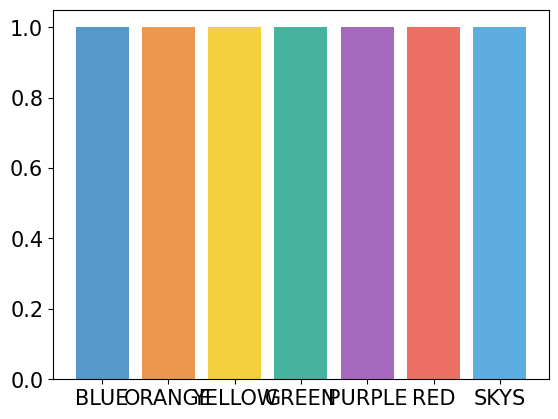

<Figure size 400x200 with 0 Axes>

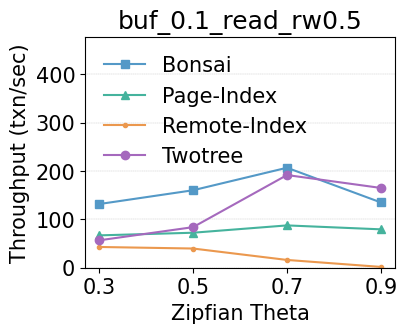

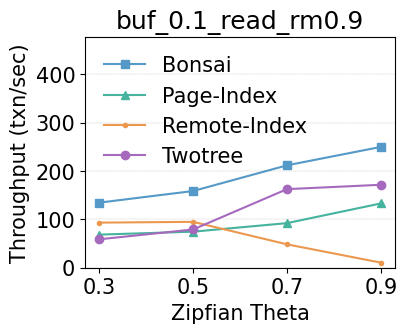

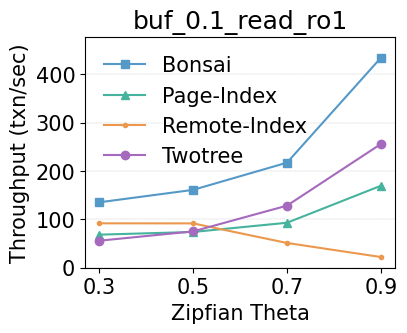

In [15]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
_, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","zipf_theta_"]
datadir = "../output/"
exp_page = "debug_exp_point_10g_page_fanout250"
exp_tuple = "debug_exp_point_10g_tuple"
exp_remote = "debug_exp_point_10g_remote"
exp_ttt = "debug_exp_point_10g_two_tree_tuple"
exp_ttb = "debug_exp_point_10g_two_tree_page"
data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
data_remote = [json.loads(line) for line in open(datadir + exp_remote + ".txt")]
df_remote = pd.DataFrame().from_records(data_remote)
data_ttt = [json.loads(line) for line in open(datadir + exp_ttt + ".txt")]
df_ttt = pd.DataFrame().from_records(data_ttt)
data_ttb = [json.loads(line) for line in open(datadir + exp_ttb + ".txt")]
df_ttb = pd.DataFrame().from_records(data_ttb)

df = pd.concat([df_page, df_tuple, df_remote, df_ttt, df_ttb])
# print(df)
df["id"] = range(df.shape[0])
df.columns


# create pivot table
df1 = apply_mask(df, [
    ["g_buf_type", ["eq", "OBJBUF"]]
])
df1 = apply_mask(df1, [
    ["g_total_buf_sz", ["eq", 1200000000]]
])
pivot = df1.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "remote_rd_time_ms", "remote_rds_", "commit_cnt_"
]].max()
pivot

# create pivot table
# df2 = apply_mask(df, [
#     ["g_buf_type", ["eq", "PGBUF"]],
#     ["g_total_buf_sz", ["eq", "1200000000"]]
# ])
df2 = apply_mask(df, [
    ["g_buf_type", ["eq", "PGBUF"]]
])
# print(idxs)
# print("pv2")
# print(df2)

df2 = apply_mask(df2, [
    ["g_total_buf_sz", ["eq", 1200000000]]
])
pivot2 = df2.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "remote_rd_time_ms", "remote_rds_", "commit_cnt_"
    ]].max()
# print("pv2 hahha")
# print(pivot2)

# create pivot table
# df0 = pd.DataFrame().from_records([json.loads(line) for line in open(datadir + "different_settings/" + 
#                                                                      "microbench_zipf_10g_fanout18.out")])
df3 = apply_mask(df, [
    ["g_buf_type", ["eq", "NOBUF"]]
])
pivot3 = df3.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "g_buf_type", "remote_rds_"
]].max()
# print("hahah")
# print(pivot3)

df_tt_1 = apply_mask(df, [
    ["g_buf_type", ["eq", "OBJBUF"]]
])

df_tt_1 = apply_mask(df_tt_1, [
    ["g_total_buf_sz", ["eq", 1080000000]]
])
pivot_tt_1 = df_tt_1.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "g_buf_type", "remote_rds_"
]].max()

# print("pivot_tt_1 hahha")
# print(pivot_tt_1)

df_tt_2 = apply_mask(df, [
    ["g_buf_type", ["eq", "PGBUF"]],
])

df_tt_2 = apply_mask(df_tt_2, [
    ["g_total_buf_sz", ["eq", 120000000]]
])


pivot_tt_2 = df_tt_2.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "g_buf_type", "remote_rds_"
]].max()

# print("pivot_tt_2 hahha")
# print(pivot_tt_2)



import matplotlib.ticker as mtick
def y_axis_formatter(x, pos):
    # Check if the value is in the thousands
    if x >= 1000:
        # Format as "1k" and divide by 1000
        return f"{int(x/1000)}k"
    else:
        return "%.1fk"%(x / 1000.0)
workload_col = 0
zipf_col = 2
read_col = 1
# pivot = pivot2
workload_ratio = [sz / 10240000000.0 for sz in pivot.index.levels[workload_col]]
workload_names = ["s", "m", "l", "xl"]
read_names = ["rw", "rm", "ro"]
buf_ratio = ["0.1"]
read_ratio = ["0.5", "0.9", "1"]
zipf_names = ["zf%.f"%(z * 10) for z in pivot.index.levels[zipf_col]]
# path = "~/Desktop/Bonsai/figures/point_by_size/"
zipf_names
for i, x in enumerate(pivot.index.levels[workload_col]):
    plot_data = pivot.loc[x]
    plot_data2 = pivot2.loc[x]
    # plot_data3 = pivot3.loc[0]
    plot_data3 = pivot3.loc[x]
    plot_data4 = pivot_tt_1.loc[pivot_tt_1.index.levels[workload_col][i]] 
    plot_data5 = pivot_tt_2.loc[pivot_tt_2.index.levels[workload_col][i]] 
    max_throughput = max(plot_data["throughput_txn_per_sec"].max(), plot_data2["throughput_txn_per_sec"].max()) * 1.1 
    for j, y in enumerate(pivot.index.levels[read_col]):
        plot_data_tt = plot_data4.loc[y]["hit_rate_"] * plot_data4.loc[y]["throughput_txn_per_sec"] + (1 - plot_data4.loc[y]["hit_rate_"]) * plot_data5.loc[y]["throughput_txn_per_sec"]
        # plot_data_tt1 = plot_data4.loc[y]["hit_rate_"] * plot_data.loc[y]["throughput_txn_per_sec"] + (1 - plot_data4.loc[y]["hit_rate_"]) * plot_data5.loc[y]["throughput_txn_per_sec"]
        fig, ax = plt.subplots()
        # xval = range(len(pivot.index.levels[read_col]))
        xval = pivot.index.levels[zipf_col]
        
        ax.plot(xval, 
                plot_data.loc[y]["throughput_txn_per_sec"],
                color=line_colors["BLUE"],
                marker="s", label="Bonsai")
        ax.plot(xval, 
                plot_data2.loc[y]["throughput_txn_per_sec"],
                color=line_colors["GREEN"],
                marker="^", label="Page-Index")
        ax.plot(xval, 
                plot_data3.loc[y]["throughput_txn_per_sec"],
                color=line_colors["ORANGE"],
                marker=".", label="Remote-Index")

        ax.plot(xval, 
                plot_data_tt,
                color=line_colors["PURPLE"],
                marker="o", label="Twotree")
        
        # ax.plot(xval, 
        #         plot_data_tt1,
        #         color=line_colors["RED"],
        #         marker="o", label="Twotree")
        # ax.plot(xval, 
        #         plot_data4.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["RED"],
        #         marker=".", label="Twotree-Top")
        # ax.plot(xval, 
        #         plot_data5.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["YELLOW"],
        #         marker=".", label="Twotree-Down")
        ax.set_ylim(0, max_throughput)
        #ax.set_xlim(0, 1)
        ax.set_xticks(xval)
        location = "upper left"
        if i == 3:
            location = "lower left"
        ax.legend(loc=location, frameon=False)
        ax.set_ylabel("Throughput (txn/sec)")
        ax.set_xlabel("Zipfian Theta")
        ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
        #ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
        ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
        fig.set_size_inches(4, 3)
        # fig.savefig(path + "point_10g_fanout250_limit16k_{}_{}.pdf".format(
        #     workload_names[i], read_names[j]), bbox_inches="tight")    